In [1]:
import os
# These two lines tell TensorFlow to skip the failing autotuner
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'

import tensorflow as tf

# Standard practice to avoid memory crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Ready and Autotuner disabled.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1774372770.296099   44242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774372770.329237   44242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774372771.153008   44242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Ready and Autotuner disabled.


W0000 00:00:1774372772.192771   44242 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
# 0 = All logs, 1 = Filter INFO, 2 = Filter INFO/WARNING, 3 = Filter all

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import os
import pickle

In [ ]:
# Hyperparameters
img_height = 128
img_width = 128
batch_size = 32
learning_rate = 1e-4
epochs = 30

# Dataset paths
train_dir = r"Image_Dataset/Combined Dataset/train"
test_dir = r"Image_Dataset/Combined Dataset/test"

In [5]:
# Data Preprocessing
def data_preprocessing(output_size, val_split=0.1):
    train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, shear_range=0.2,
                                       rotation_range=15, fill_mode='nearest',
                                       horizontal_flip=True, validation_split=val_split)

    training_set = train_datagen.flow_from_directory(
        train_dir, target_size=(output_size, output_size),
        batch_size=batch_size, class_mode='categorical',
        shuffle=True, subset='training')

    validation_set = train_datagen.flow_from_directory(
        train_dir, target_size=(output_size, output_size),
        batch_size=batch_size, class_mode='categorical',
        shuffle=True, subset='validation')

    return training_set, validation_set

In [6]:
# Test Data Preprocessing
def test_data_preprocessing(output_size):
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_set = test_datagen.flow_from_directory(
        test_dir, target_size=(output_size, output_size),
        batch_size=batch_size, class_mode='categorical',
        shuffle=False)
    return test_set

In [7]:
def compute_class_weights(train_generator):
    class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
    return {i: weight for i, weight in enumerate(class_weights)}

In [8]:
# CNN Model
def build_custom_cnn_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'],
                  jit_compile=False)
    return model

In [9]:
def evaluate_model(model, test_generator):
    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())
    print("\nClassification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=2))

In [10]:
# Plot training history
def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

In [11]:
# Main function
def main():
    train_generator, val_generator = data_preprocessing(output_size=128, val_split=0.1)
    test_generator = test_data_preprocessing(output_size=128)
    class_weights = compute_class_weights(train_generator)
    model = build_custom_cnn_model()

    # Save class indices for later use in prediction
    with open("class_indices.pkl", "wb") as f:
        pickle.dump(train_generator.class_indices, f)

    callbacks = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

    print("\nStarting training...")
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=callbacks,
        class_weight=class_weights
    )

    plot_training_history(history, title="CNN Training")
    model.save('alzheimers_cnn_model.h5')
    print("Model saved as 'alzheimers_cnn_model.h5'")

    loaded_model = load_model('alzheimers_cnn_model.h5')
    print("Model loaded successfully!")
    evaluate_model(loaded_model, test_generator)

Found 6656 images belonging to 3 classes.
Found 739 images belonging to 3 classes.
Found 788 images belonging to 3 classes.


/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1774372791.162063   44242 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774372791.270881   44242 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1774372791.427877   44496 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.5.40, which corresponds to a CUDA v


Starting training...
Epoch 1/30


I0000 00:00:1774372791.915991   44242 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1774372793.422799   44488 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372793.593579   44571 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372793.595042   44573 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372793.597138   44569 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372793.598560   44570 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372793.600326   44576 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas.

  1/208 ━━━━━━━━━━━━━━━━━━━━ 32:02 9s/step - accuracy: 0.3125 - loss: 2.5302

W0000 00:00:1774372801.020465   44487 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1774372801.102905   44487 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


208/208 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.6902 - loss: 1.3805 - val_accuracy: 0.3072 - val_loss: 6.2057 - learning_rate: 1.0000e-04
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8453 - loss: 0.8423 - val_accuracy: 0.3072 - val_loss: 4.0528 - learning_rate: 1.0000e-04
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.8688 - loss: 0.7352 - val_accuracy: 0.8796 - val_loss: 0.7297 - learning_rate: 1.0000e-04
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.8867 - loss: 0.6625 - val_accuracy: 0.9445 - val_loss: 0.5103 - learning_rate: 1.0000e-04
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8972 - loss: 0.6114 - val_accuracy: 0.9323 - val_loss: 0.5010 - learning_rate: 1.0000e-04
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9032 - loss: 0.5689 - val_accuracy: 0.9499 - val_loss: 0.4438 - learning_rate: 1.0000e-04
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accurac

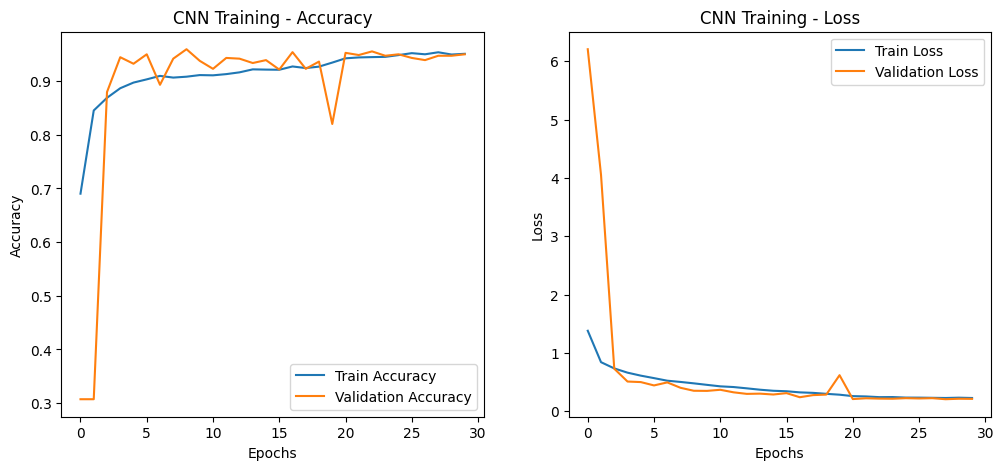

Model saved as 'alzheimers_cnn_model.h5'
Model loaded successfully!


I0000 00:00:1774373218.941578   44487 service.cc:153] XLA service 0x70afa1db7750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774373218.941616   44487 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774373218.946772   44487 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1774373219.248380   44487 op_kernel.cc:1858] OP_REQUIRES failed at xla_ops.cc:602 : INTERNAL: Autotuner could not compile any configs for HLO: %gemm_fusion_MatMul.6 = f32[32,3]{1,0} fusion(%gemm_fusion_MatMul.4, %arg21.1, %arg22.1), kind=kCustom, calls=%gemm_fusion_MatMul.6_computation, frontend_attributes={grad_x="false",grad_y="false"}, metadata={op_type="MatMul" op_name="sequential_1/dense_1_2/MatMul" source_file="/home/arther/miniconda3/envs/tf216/lib/python3

InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/base_events.py", line 683, in run_forever

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/base_events.py", line 2050, in _run_once

  File "/home/arther/miniconda3/envs/tf216/lib/python3.13/asyncio/

In [12]:
if __name__ == "__main__":
    main()

In [2]:
import os
# Hardware Stabilization (Essential for your RTX 5060)
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report

# Setup Paths and Parameters
img_size = 128 
test_dir = "Image_Dataset/Combined Dataset/test"

# Load the Saved Optimized Model

model = load_model('alzheimers_cnn_model.h5', compile=False)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

# Prepare Test Data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate and Print Text Report
print("\nGenerating predictions...")
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("\n" + "="*30)
print("  OPTIMIZED MODEL REPORT")
print("="*30)
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

Found 788 images belonging to 3 classes.

Generating predictions...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

  OPTIMIZED MODEL REPORT
                     precision    recall  f1-score   support

    Mild Impairment     0.9254    0.9394    0.9323       264
Moderate Impairment     1.0000    0.9962    0.9981       264
      No Impairment     0.9377    0.9269    0.9323       260

           accuracy                         0.9543       788
          macro avg     0.9544    0.9542    0.9542       788
       weighted avg     0.9545    0.9543    0.9544       788

